# 04 — Backtesting y Construcción de Cartera

**Objetivo.** Transformar las predicciones out-of-sample del modelo XGBoost (notebook 03) en una estrategia de inversión cuantitativa, evaluando rigurosamente su perfil rentabilidad/riesgo bajo fricciones de mercado realistas. La construcción de cartera se desarrolla de forma **incremental**: partiendo de un baseline, se añaden palancas de *portfolio construction* una a una, cuantificando el aporte marginal de cada decisión.

---

### Alcance y delimitación

El notebook se restringe a **portfolio construction y backtesting**. El modelo predictivo queda congelado y no se modifica. Las palancas evaluadas operan exclusivamente sobre la transformación *predicciones → pesos → P&L*. Esta separación es la convención industrial en *quant equity* entre **modelado** (notebook 03) y **portfolio construction** (este notebook).

### Metodología: ablación incremental

Cada estrategia se construye **acumulativamente** sobre la anterior. Esta arquitectura permite atribuir el aporte marginal de cada palanca y mantiene la coherencia con la metodología de ablación ya aplicada en el notebook 03.

| # | Estrategia | Palanca añadida | Pregunta que responde |
|---|---|---|---|
| 0 | Baseline | Deciles equal-weight (largo top 10%, corto bottom 10%) | Punto de partida del notebook 03 |
| 1 | Weighted ranking | Pesos continuos proporcionales al rank de la predicción | ¿Explotar el ordering completo mejora el Sharpe? |
| 2 | + Volatility scaling | Pesos divididos por volatilidad reciente (Garman-Klass) | ¿Igualar la contribución al riesgo aporta? |
| 3 | + Beta-neutralización | Beta agregada al S&P 500 proyectada a cero | ¿Eliminar exposición direccional residual estabiliza el Sharpe? |
| 4 | + EWMA smoothing | Suavizado temporal de predicciones (*halflife* = 2) | ¿La reducción de *turnover* compensa la pérdida de información? |
| 5 | Ensemble | Combinación lineal Ridge + XGBoost sobre el pipeline completo | ¿Promediar modelos añade robustez? |
| 6 | + Magnitude weighting | Pesos ∝ \|predicción\| en lugar de rank, sobre el ensemble | ¿La magnitud de la regresión aporta información sobre el rank? |

Las palancas no son monotónicamente positivas — alguna podría deteriorar el Sharpe. Este resultado es un *finding* legítimo y se reporta con honestidad metodológica: la estrategia final se selecciona por evidencia empírica, no por orden de implementación.

### Decisiones técnicas

| Decisión | Valor | Justificación |
|---|---|---|
| **Notional** | Gross = 2 (*dollar-neutral*) | Convención hedge-fund: \$1 en largos + \$1 en cortos. |
| **Frecuencia de rebalanceo** | Diaria | Coherente con el horizonte de predicción a 1 día. |
| **Costes** | 1 bp fijo + *slippage* proporcional a Amihud | Modelo simple, defendible y alineado con la literatura. |
| **Universo** | 500+ activos del S&P 500 | Mismo que los notebooks 01–03. |
| **Periodo** | 2016–2024 (out-of-sample del notebook 03) | Estrictamente *unseen* por el modelo. |

### Robustez estadística

La estrategia ganadora se somete a tres pruebas de robustez:

1. **Bootstrap** (10 000 muestras): intervalo de confianza del Sharpe.
2. **Permutation test** (1 000 muestras): *p-value* empírico vs aleatorización de predicciones.
3. **Estabilidad por sub-periodos**: comparación entre la primera y segunda mitad del periodo de test.

### Entradas y salidas

| Tipo | Archivo | Generado por |
|------|---------|--------------|
| Input  | `data/predictions_oos.parquet`        | notebook 03 |
| Input  | `data/feature_store.parquet`          | notebook 02 |
| Input  | `data/massive_financial_data.parquet` | notebook 01 |
| Input  | `data/model_training_metadata.json`   | notebook 03 |
| Output | `data/portfolio_returns_all.parquet`  | este notebook (consumido por el dashboard) |
| Output | `data/portfolio_weights_final.parquet`| este notebook |
| Output | `data/backtest_metadata.json`         | este notebook |

## 1. Configuración del entorno

Inicialización de imports, resolución robusta de rutas (consistente con los notebooks previos), *logging* estructurado y declaración de constantes financieras.

**Constantes canónicas:**

- `TRADING_DAYS_YEAR = 252` — Factor de anualización (días hábiles).
- `COMMISSION_BPS = 1` — Comisión fija por operación. Refleja el régimen de **ejecución algorítmica institucional** (*prime broker* de *hedge fund*), donde las comisiones efectivas son significativamente inferiores a las del segmento retail. Frazzini, Israel & Moskowitz (2018) reportan comisiones efectivas en el rango 0.5–1.5 bps para fondos institucionales en US equities.
- `SLIPPAGE_AMIHUD_COEF` — Coeficiente que escala el *ratio* de Amihud para producir *slippage* en bps. Se calibra empíricamente mediante búsqueda binaria de forma que el *slippage* medio del universo, **tras aplicar el cap superior**, sea ≈ 3 bps. La calibración por **media** (no mediana) es necesaria dado el sesgo fuerte de la distribución del Amihud Ratio: la mediana es estable pero la media sin cap diverge por outliers de activos iliquidos.
- `MAX_SLIPPAGE_BPS = 30` — Cota superior del *slippage* por operación. Frazzini et al. (2018) documentan medianas de 15–25 bps incluso para activos menos líquidos. Valores superiores son atípicos en US equities con ejecución algorítmica institucional; el cap a 30 bps es realista y conservador.
- `EWMA_HALFLIFE = 2` — *Halflife* del suavizado EWMA de predicciones, sujeto a análisis de sensibilidad.
- `BOOTSTRAP_N = 10_000`, `PERMUTATION_N = 1_000` — Tamaños muestrales de los tests de robustez.

In [1]:
import json
import logging
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

# Logging estructurado consistente con notebooks anteriores
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("backtesting")

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

In [2]:
# --- Resolución robusta de la raíz del proyecto ---
def _find_project_root(marker: str = "data", max_levels: int = 3) -> Path:
    """Localiza la raíz del proyecto buscando el directorio 'data/'."""
    here = Path.cwd()
    for candidate in [here, *list(here.parents)[:max_levels]]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(
        f"No se encontró el directorio '{marker}/' partiendo de {here}."
    )

PROJECT_ROOT = _find_project_root()
DATA_DIR     = PROJECT_ROOT / "data"

# --- Inputs ---
PREDICTIONS_FILE   = DATA_DIR / "predictions_oos.parquet"
FEATURE_STORE_FILE = DATA_DIR / "feature_store.parquet"
RAW_DATA_FILE      = DATA_DIR / "massive_financial_data.parquet"
MODEL_METADATA     = DATA_DIR / "model_training_metadata.json"

# --- Outputs ---
PORTFOLIO_RETURNS_FILE = DATA_DIR / "portfolio_returns_all.parquet"
PORTFOLIO_WEIGHTS_FILE = DATA_DIR / "portfolio_weights_final.parquet"
BACKTEST_METADATA_FILE = DATA_DIR / "backtest_metadata.json"

# Verificación temprana
for f in [PREDICTIONS_FILE, FEATURE_STORE_FILE, RAW_DATA_FILE]:
    if not f.exists():
        raise FileNotFoundError(f"No se encontró {f}. Ejecuta los notebooks previos.")

logger.info(f"PROJECT_ROOT     : {PROJECT_ROOT}")
logger.info(f"PREDICTIONS_FILE : {PREDICTIONS_FILE}")

11:39:10 | INFO     | PROJECT_ROOT     : c:\Users\Usuario\Desktop\bachelor-thesis
11:39:10 | INFO     | PREDICTIONS_FILE : c:\Users\Usuario\Desktop\bachelor-thesis\data\predictions_oos.parquet


In [3]:
# --- Constantes financieras ---
TRADING_DAYS_YEAR     = 252      # estándar para anualización
BENCHMARK             = "^GSPC"  # S&P 500 (notebook 01)

# --- Modelo de costes de transacción ---
COMMISSION_BPS        = 1.0      # comisión por operación (ejecución algorítmica institucional)
SLIPPAGE_AMIHUD_COEF  = 1e9      # coeficiente Amihud → bps; recalibrado en sección 10
MAX_SLIPPAGE_BPS      = 30.0     # cota superior del slippage por operación

# --- Hiperparámetros de las palancas ---
ROLLING_WINDOW_VOL    = 20       # ventana para volatility scaling y beta
EWMA_HALFLIFE         = 2        # suavizado temporal de predicciones

# --- Parámetros de robustez ---
BOOTSTRAP_N           = 10_000   # muestras para intervalo de confianza del Sharpe
PERMUTATION_N         = 200    # permutaciones para test de no-aleatoriedad

logger.info(f"Costes: {COMMISSION_BPS:.1f} bps + slippage(Amihud)")
logger.info(f"EWMA halflife: {EWMA_HALFLIFE}, ventana vol/beta: {ROLLING_WINDOW_VOL}")

11:39:10 | INFO     | Costes: 1.0 bps + slippage(Amihud)
11:39:10 | INFO     | EWMA halflife: 2, ventana vol/beta: 20


## 2. Carga de datos

Se cargan los cuatro inputs requeridos:

1. **Predicciones out-of-sample** (`predictions_oos.parquet`): panel `(Date, Ticker)` con `y_true` (retorno realizado) y `y_pred` (predicción XGBoost).
2. **Feature store**: requerido para extraer `Garman_Klass_Vol` (*volatility scaling*) y `Amihud_Ratio` (*slippage*).
3. **OHLCV crudo**: necesario para los retornos del *benchmark* `^GSPC` (estimación de beta) y como referencia.
4. **Metadata del modelo**: hiperparámetros y métricas del notebook 03 para trazabilidad.

In [4]:
# 1. Predicciones del modelo (output del notebook 03)
predictions = pd.read_parquet(PREDICTIONS_FILE)
logger.info(f"Predicciones cargadas: {predictions.shape}")

# 2. Feature store (para volatility scaling y slippage)
feature_store = pd.read_parquet(FEATURE_STORE_FILE)
logger.info(f"Feature store cargado: {feature_store.shape}")

# 3. Datos OHLCV crudos (para retornos del benchmark)
raw_ohlcv = pd.read_parquet(RAW_DATA_FILE)
logger.info(f"OHLCV crudo cargado: {raw_ohlcv.shape}")

# 4. Metadata del modelo
with open(MODEL_METADATA, "r", encoding="utf-8") as f:
    model_metadata = json.load(f)
logger.info(f"Modelo entrenado el: {model_metadata['training_timestamp_utc']}")

# Sanity checks
assert predictions.index.names == ["Date", "Ticker"], "Estructura del MultiIndex inesperada."
assert {"y_true", "y_pred"}.issubset(predictions.columns), "Faltan columnas en predicciones."
assert "Garman_Klass_Vol" in feature_store.columns, "Falta Garman_Klass_Vol en feature store."
assert "Amihud_Ratio"     in feature_store.columns, "Falta Amihud_Ratio en feature store."

# Información descriptiva
dates_test = predictions.index.get_level_values("Date").unique()
print(f"Período de backtest      : {dates_test.min().date()} → {dates_test.max().date()}")
print(f"Días totales             : {len(dates_test):,}")
print(f"Tickers únicos           : {predictions.index.get_level_values('Ticker').nunique()}")
print(f"Filas de predicción      : {len(predictions):,}")

11:39:10 | INFO     | Predicciones cargadas: (1103511, 3)
11:39:10 | INFO     | Feature store cargado: (2402184, 17)
11:39:11 | INFO     | OHLCV crudo cargado: (5295, 2525)
11:39:11 | INFO     | Modelo entrenado el: 2026-05-05T08:43:42.810690+00:00


Período de backtest      : 2016-01-04 → 2024-12-31
Días totales             : 2,269
Tickers únicos           : 501
Filas de predicción      : 1,103,511


### 2.1 Regeneración de predicciones del baseline Ridge

La estrategia 5 (ensemble Ridge + XGBoost) requiere las predicciones de Ridge sobre los mismos folds out-of-sample. Como el notebook 03 no las persiste, se regeneran en este punto — el coste computacional es marginal (~5 s) y se mantiene una arquitectura limpia donde el notebook 03 produce únicamente el modelo principal.

Se replica exactamente la metodología del notebook 03: target *cross-sectionally demeaned* para entrenamiento, evaluación contra retorno realizado, mismos folds *walk-forward*.

In [5]:
# Reconstruir folds idénticos al notebook 03
TRAIN_START_YEAR = 2005
FIRST_VAL_YEAR   = 2015
LAST_VAL_YEAR    = 2023
PURGE_DAYS       = 5

unique_dates = pd.DatetimeIndex(sorted(set(feature_store.index.get_level_values("Date"))))


def _generate_folds_for_ridge() -> list[dict]:
    """Reconstruye los folds del notebook 03 para regenerar Ridge."""
    folds = []
    sorted_dates = unique_dates
    for i, val_year in enumerate(range(FIRST_VAL_YEAR, LAST_VAL_YEAR + 1), start=1):
        val_dates  = sorted_dates[(sorted_dates >= pd.Timestamp(f"{val_year}-01-01")) &
                                   (sorted_dates <= pd.Timestamp(f"{val_year}-12-31"))]
        test_dates = sorted_dates[(sorted_dates >= pd.Timestamp(f"{val_year+1}-01-01")) &
                                   (sorted_dates <= pd.Timestamp(f"{val_year+1}-12-31"))]
        if len(val_dates) == 0 or len(test_dates) == 0:
            continue
        train_end_idx = sorted_dates.get_indexer([val_dates[0]])[0] - PURGE_DAYS - 1
        if train_end_idx <= 0:
            continue
        folds.append({
            "fold":        i,
            "train_start": pd.Timestamp(f"{TRAIN_START_YEAR}-01-01"),
            "train_end":   sorted_dates[train_end_idx],
            "test_start":  test_dates[0],
            "test_end":    test_dates[-1],
        })
    return folds


# Preparar matrices alineadas con el feature store
target_col   = "Target_FwdRet_1D"
feature_cols = [c for c in feature_store.columns if not c.startswith("Target")]
X_full     = feature_store[feature_cols]
y_raw_full = feature_store[target_col]
y_full     = y_raw_full.groupby(level="Date").transform(lambda s: s - s.mean())

# Walk-forward Ridge
ridge_preds_list = []
for fold in _generate_folds_for_ridge():
    dates = X_full.index.get_level_values("Date")
    train_mask = (dates >= fold["train_start"]) & (dates <= fold["train_end"])
    test_mask  = (dates >= fold["test_start"])  & (dates <= fold["test_end"])

    scaler = StandardScaler().fit(X_full[train_mask])
    model  = Ridge(alpha=1.0, random_state=SEED)
    model.fit(scaler.transform(X_full[train_mask]), y_full[train_mask])
    pred_test = model.predict(scaler.transform(X_full[test_mask]))

    ridge_preds_list.append(pd.DataFrame({
        "y_pred_ridge": pred_test
    }, index=X_full[test_mask].index))

ridge_preds = pd.concat(ridge_preds_list)
logger.info(f"Predicciones Ridge regeneradas: {ridge_preds.shape}")

# Unir con las predicciones de XGBoost
predictions = predictions.join(ridge_preds, how="inner")
predictions = predictions.rename(columns={"y_pred": "y_pred_xgb"})
logger.info(f"Panel final de predicciones: {predictions.shape}")
print(predictions.head())

11:39:20 | INFO     | Predicciones Ridge regeneradas: (1103511, 1)
11:39:20 | INFO     | Panel final de predicciones: (1103511, 4)


                     y_true  y_pred_xgb  fold  y_pred_ridge
Date       Ticker                                          
2016-01-04 CFG    -0.004651    0.000005     1      0.000053
           MDLZ    0.008221   -0.000087     1     -0.000141
           CMS     0.007863    0.000060     1      0.000164
           RVTY    0.011062    0.000189     1      0.000056
           GLW    -0.000558   -0.000211     1     -0.000357


## 3. Framework de backtesting

El motor de backtest se diseña bajo el principio de **separación de responsabilidades**:

- Una **estrategia** es una función pura que produce un panel de pesos `(Date, Ticker) → weight`.
- El **motor** aplica esos pesos a los retornos realizados y deriva métricas.
- Los **costes de transacción** se modelan como una capa separable.

La arquitectura garantiza la comparabilidad entre estrategias y habilita la extensión a futuras palancas sin modificar el motor.

### 3.1 Convenciones de pesos

Para una cartera *long-short dollar-neutral* con notional gross = 2:

$$
\sum_{i: w_i > 0} w_i = 1, \quad \sum_{i: w_i < 0} w_i = -1, \quad \sum_i |w_i| = 2
$$

El retorno diario de la cartera viene dado por:

$$
R_t = \sum_i w_{i,t} \cdot r_{i,t+1}
$$

donde $r_{i,t+1}$ es el retorno realizado del activo $i$ entre $t$ y $t+1$ (`y_true` en el panel de predicciones).

### 3.2 Modelo de costes

El coste de la operación del activo $i$ en el día $t$ se modela como:

$$
\text{coste}_{i,t} = \Bigl(c_{\text{fix}} + \min\bigl(\alpha \cdot \text{Amihud}_{i,t},\ s_{\max}\bigr)\Bigr) \cdot |w_{i,t} - w_{i,t-1}|
$$

donde:

- $c_{\text{fix}} = 1$ bp: comisión fija (ejecución algorítmica institucional).
- $\alpha \cdot \text{Amihud}_{i,t}$: *slippage* proporcional al *ratio* de iliquidez.
- $s_{\max} = 30$ bps: cota superior del *slippage* por operación.
- $|w_{i,t} - w_{i,t-1}|$: *turnover* absoluto de la posición.

#### Justificación del cap del slippage

El *ratio* de Amihud, como proxy de iliquidez, presenta una distribución fuertemente sesgada: la cola superior contiene observaciones donde el indicador alcanza valores extremos (volúmenes muy bajos o eventos atípicos) que, sin acotar, producirían *slippages* operativamente imposibles (millones de bps por operación). En la operativa real, los costes de ejecución a horizonte diario en US equities están acotados por la presencia de *market makers* y *liquidity providers*; Frazzini, Israel & Moskowitz (*Trading Costs of Asset Pricing Anomalies*, 2018) documentan medianas de 15–25 bps incluso para activos menos líquidos en US equities con ejecución algorítmica institucional.

El coeficiente $\alpha$ se calibra empíricamente en la **sección 10** mediante búsqueda binaria, de forma que el *slippage* **medio** del universo (tras aplicar el cap) sea ≈ 3 bps. La calibración por media — y no por mediana — garantiza que las métricas agregadas (suma de costes diarios) reflejen un coste realista, dado que la distribución del Amihud es *lognormal-like*.

El coste **total** por operación (comisión + *slippage* medio) resulta ≈ **4 bps**, alineado con la literatura empírica para ejecución institucional en US large/mid caps.

In [6]:
def normalize_dollar_neutral(weights: pd.Series) -> pd.Series:
    """
    Normaliza pesos a notional gross = 2 (dollar-neutral).

    Para cada fecha: largos suman +1, cortos suman -1.
    Si todos los pesos de un día tienen el mismo signo, se normaliza por su suma absoluta.

    Parameters
    ----------
    weights : pd.Series con MultiIndex (Date, Ticker)

    Returns
    -------
    pd.Series con la misma estructura, pesos normalizados.
    """
    def _normalize_day(w: pd.Series) -> pd.Series:
        long_sum  = w[w > 0].sum()
        short_sum = -w[w < 0].sum()  # positivo
        out = w.copy()
        if long_sum > 0:
            out[w > 0] = w[w > 0] / long_sum
        if short_sum > 0:
            out[w < 0] = w[w < 0] / short_sum
        return out

    return weights.groupby(level="Date").transform(_normalize_day)


def compute_portfolio_returns(weights: pd.Series, realized_returns: pd.Series) -> pd.Series:
    """
    Aplica pesos a retornos realizados para obtener retorno diario del portfolio.

    El peso w_t se aplica al retorno r_{t+1} → al ser y_true ya el retorno forward,
    el cálculo es directo: R_t = sum_i w_{i,t} * y_true_{i,t}.
    """
    df = pd.DataFrame({"w": weights, "r": realized_returns}).dropna()
    return df.groupby(level="Date").apply(lambda g: (g["w"] * g["r"]).sum())


def compute_turnover(weights: pd.Series) -> pd.Series:
    """
    Calcula turnover diario = sum_i |w_{i,t} - w_{i,t-1}|.

    El turnover representa el volumen total operado en cada día.
    Para una cartera dollar-neutral con notional gross = 2, el turnover máximo
    teórico es 4 (rotación completa de todas las posiciones).
    """
    weights_wide = weights.unstack(level="Ticker").fillna(0.0)
    diff = weights_wide.diff().abs().sum(axis=1)
    return diff.rename("turnover")


def compute_costs(weights: pd.Series, amihud: pd.Series,
                  commission_bps: float = COMMISSION_BPS,
                  amihud_coef: float = SLIPPAGE_AMIHUD_COEF,
                  max_slippage_bps: float = MAX_SLIPPAGE_BPS) -> pd.Series:
    """
    Calcula los costes de transacción por día.

    coste_diario = sum_i (c_fix + min(alpha * Amihud_i, max_slip)) * |delta w_i|

    El cap superior del slippage (max_slippage_bps) refleja la realidad
    operativa: incluso en activos iliquidos, el slippage de ejecución
    a horizonte diario está limitado por market makers y liquidity providers
    (Frazzini, Israel & Moskowitz, 2018, reportan medianas 15-25 bps). Sin
    este cap, los outliers extremos de la distribución del Amihud Ratio
    producirían costes físicamente imposibles que dominarían el cálculo
    agregado.

    Returns
    -------
    pd.Series con coste diario en unidades de retorno (no en bps).
    """
    weights_wide = weights.unstack(level="Ticker").fillna(0.0)
    delta_w = weights_wide.diff().abs()

    # Slippage por activo y día, ACOTADO superiormente
    amihud_wide = amihud.unstack(level="Ticker").reindex_like(weights_wide).fillna(0.0)
    slippage_bps = (amihud_coef * amihud_wide).clip(upper=max_slippage_bps)

    # Coste total = (commission + slippage) * |delta w|
    cost_per_trade_bps = commission_bps + slippage_bps
    daily_cost_bps = (cost_per_trade_bps * delta_w).sum(axis=1)

    return (daily_cost_bps / 10_000.0).rename("daily_cost")


def compute_metrics(returns: pd.Series, costs: pd.Series | None = None,
                    label: str = "") -> dict:
    """
    Calcula métricas estándar de portfolio.

    Si se proporcionan costes, los aplica ANTES de calcular las métricas
    (Sharpe neto, retorno neto).
    """
    if costs is not None:
        net_returns = returns.sub(costs, fill_value=0.0)
    else:
        net_returns = returns

    if net_returns.std() == 0 or len(net_returns) < 30:
        return {"label": label, "n_days": len(net_returns)}

    ann_return = net_returns.mean() * TRADING_DAYS_YEAR
    ann_vol    = net_returns.std()  * np.sqrt(TRADING_DAYS_YEAR)
    sharpe     = ann_return / ann_vol if ann_vol > 0 else 0.0

    # Sortino: usa downside deviation
    downside     = net_returns[net_returns < 0]
    downside_vol = downside.std() * np.sqrt(TRADING_DAYS_YEAR) if len(downside) > 0 else 0.0
    sortino      = ann_return / downside_vol if downside_vol > 0 else 0.0

    # Drawdown
    cumulative = (1 + net_returns).cumprod()
    drawdown   = (cumulative / cumulative.cummax() - 1).min()

    # t-stat del retorno medio diario
    t_stat = net_returns.mean() / (net_returns.std() / np.sqrt(len(net_returns)))

    return {
        "label":             label,
        "ann_return":        float(ann_return),
        "ann_vol":           float(ann_vol),
        "sharpe":            float(sharpe),
        "sortino":           float(sortino),
        "max_drawdown":      float(drawdown),
        "cum_return":        float(cumulative.iloc[-1] - 1),
        "t_stat":            float(t_stat),
        "n_days":            int(len(net_returns)),
    }


logger.info("Framework de backtesting definido.")

11:39:20 | INFO     | Framework de backtesting definido.


## 4. Estrategia 0 — Baseline: deciles *equal-weight*

Se replica la estrategia del notebook anterior como punto de partida:

1. Ordenamiento *cross-sectional* de los activos por la predicción del modelo cada día.
2. **Long**: top decil (10% con predicción más alta), pesos uniformes.
3. **Short**: bottom decil (10% con predicción más baja), pesos uniformes.
4. Notional gross = 2 (largos suman +1, cortos suman −1).

Constituye la estrategia mínima y opera como referencia para cuantificar el aporte de las palancas subsiguientes.

In [7]:
def strategy_decile_equal_weight(predictions_df: pd.DataFrame,
                                  pred_col: str = "y_pred_xgb",
                                  n_quantiles: int = 10) -> pd.Series:
    """
    Genera pesos para la estrategia baseline: long top decil, short bottom decil,
    pesos iguales dentro de cada lado.

    Returns
    -------
    pd.Series con MultiIndex (Date, Ticker) y pesos en (-w, 0, +w).
    """
    df = predictions_df[[pred_col]].copy()
    df["quantile"] = (
        df.groupby(level="Date")[pred_col]
          .transform(lambda x: pd.qcut(x, n_quantiles, labels=False, duplicates="drop"))
    )

    weights = pd.Series(0.0, index=df.index)
    weights[df["quantile"] == n_quantiles - 1] = 1.0    # long top decil
    weights[df["quantile"] == 0]                = -1.0  # short bottom decil

    return normalize_dollar_neutral(weights)


# Generar pesos y backtest
weights_s0 = strategy_decile_equal_weight(predictions)
returns_s0 = compute_portfolio_returns(weights_s0, predictions["y_true"])
turnover_s0 = compute_turnover(weights_s0)

# Métricas brutas (sin costes todavía)
metrics_s0 = compute_metrics(returns_s0, label="S0_Baseline")
metrics_s0["avg_turnover"] = float(turnover_s0.mean())

print("--- Estrategia 0: Baseline (deciles equal-weight, sin costes) ---")
for k, v in metrics_s0.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

--- Estrategia 0: Baseline (deciles equal-weight, sin costes) ---
  label               : S0_Baseline
  ann_return          : 0.2032
  ann_vol             : 0.2029
  sharpe              : 1.0013
  sortino             : 1.2961
  max_drawdown        : -0.4197
  cum_return          : 4.1711
  t_stat              : 3.0045
  n_days              : 2269
  avg_turnover        : 1.7781


## 5. Estrategia 1 — *Weighted ranking* continuo

**Palanca añadida:** sustitución de deciles discretos por pesos continuos proporcionales al rank cross-sectional.

Cada activo recibe un peso proporcional a su posición percentil en el *ordering* del día:

$$
w_{i,t} = 2 \cdot (\text{rank}_{i,t}^{\text{pct}} - 0.5)
$$

donde $\text{rank}^{\text{pct}} \in [0,1]$. La transformación produce:

- $w = +1$ al activo con la predicción más alta.
- $w = -1$ al activo con la predicción más baja.
- $w \approx 0$ a los activos en el centro del ranking.

**Mecanismo:** se explota la totalidad del *ordering* del modelo, no únicamente sus extremos. Un activo en el percentil 90 contribuye más que uno en el percentil 70, en lugar de pesar idéntico (deciles) o sólo uno de los dos (binarización por decil extremo).

Tras la generación de pesos crudos se aplica re-normalización a notional gross = 2.

In [8]:
def strategy_weighted_ranking(predictions_df: pd.DataFrame,
                              pred_col: str = "y_pred_xgb") -> pd.Series:
    """
    Pesos continuos proporcionales al rank cross-sectional de la predicción.
    """
    df = predictions_df[[pred_col]].copy()
    rank_pct = (
        df.groupby(level="Date")[pred_col]
          .transform(lambda x: x.rank(pct=True))
    )
    raw_weights = 2.0 * (rank_pct - 0.5)  # [-1, +1]
    return normalize_dollar_neutral(raw_weights)


weights_s1  = strategy_weighted_ranking(predictions)
returns_s1  = compute_portfolio_returns(weights_s1, predictions["y_true"])
turnover_s1 = compute_turnover(weights_s1)

metrics_s1 = compute_metrics(returns_s1, label="S1_WeightedRanking")
metrics_s1["avg_turnover"] = float(turnover_s1.mean())

print("--- Estrategia 1: Weighted ranking (sin costes) ---")
for k, v in metrics_s1.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

# Comparación incremental
delta_sharpe = metrics_s1["sharpe"] - metrics_s0["sharpe"]
print(f"\nΔ Sharpe vs Baseline: {delta_sharpe:+.4f}")

--- Estrategia 1: Weighted ranking (sin costes) ---
  label               : S1_WeightedRanking
  ann_return          : 0.1204
  ann_vol             : 0.1200
  sharpe              : 1.0031
  sortino             : 1.2771
  max_drawdown        : -0.2706
  cum_return          : 1.7705
  t_stat              : 3.0099
  n_days              : 2269
  avg_turnover        : 1.2796

Δ Sharpe vs Baseline: +0.0018


## 6. Estrategia 2 — *Weighted ranking* + *Volatility scaling*

**Palanca añadida:** división de cada peso por la volatilidad reciente del activo.

$$
w'_{i,t} = \frac{w_{i,t}}{\sigma_{i,t}}
$$

donde $\sigma_{i,t}$ es la volatilidad Garman-Klass anualizada (notebook 02, ventana de 20 días).

**Mecanismo:** sin escalado, dos activos con idéntica señal contribuyen al *portfolio* con idéntico peso; si uno presenta el doble de volatilidad, también aporta el doble de varianza. Dividir por $\sigma$ **iguala la contribución al riesgo** de cada posición — aplicación del principio de *risk parity* a nivel de activo individual.

Tras el escalado se re-normaliza a notional gross = 2.

In [9]:
def strategy_weighted_ranking_vol_scaled(predictions_df: pd.DataFrame,
                                          feature_store: pd.DataFrame,
                                          pred_col: str = "y_pred_xgb") -> pd.Series:
    """
    Pesos del ranking continuo divididos por volatilidad Garman-Klass.
    """
    raw_weights = strategy_weighted_ranking(predictions_df, pred_col)
    vol = feature_store["Garman_Klass_Vol"].reindex(raw_weights.index)

    # Evitar división por cero o NaN
    vol = vol.fillna(vol.median()).clip(lower=1e-4)

    scaled = raw_weights / vol
    return normalize_dollar_neutral(scaled)


weights_s2  = strategy_weighted_ranking_vol_scaled(predictions, feature_store)
returns_s2  = compute_portfolio_returns(weights_s2, predictions["y_true"])
turnover_s2 = compute_turnover(weights_s2)

metrics_s2 = compute_metrics(returns_s2, label="S2_VolScaled")
metrics_s2["avg_turnover"] = float(turnover_s2.mean())

print("--- Estrategia 2: + Volatility scaling (sin costes) ---")
for k, v in metrics_s2.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

delta_sharpe = metrics_s2["sharpe"] - metrics_s1["sharpe"]
print(f"\nΔ Sharpe vs Estrategia 1: {delta_sharpe:+.4f}")

--- Estrategia 2: + Volatility scaling (sin costes) ---
  label               : S2_VolScaled
  ann_return          : 0.2662
  ann_vol             : 0.2175
  sharpe              : 1.2237
  sortino             : 1.7083
  max_drawdown        : -0.2673
  cum_return          : 7.9226
  t_stat              : 3.6720
  n_days              : 2269
  avg_turnover        : 1.3304

Δ Sharpe vs Estrategia 1: +0.2206


## 7. Estrategia 3 — + Beta-neutralización

**Palanca añadida:** ajuste de pesos para imponer beta agregada del *portfolio* respecto al S&P 500 estrictamente nula.

### 7.1 Formulación

Para cada activo $i$ en la fecha $t$, se estima su beta rolling al S&P 500:

$$
\beta_{i,t} = \frac{\text{Cov}(r_i, r_m)_{t,20}}{\text{Var}(r_m)_{t,20}}
$$

La beta agregada del *portfolio* es:

$$
\beta_{P,t} = \sum_i w_{i,t} \cdot \beta_{i,t}
$$

Para imponer $\beta_{P,t} = 0$ se ajustan los pesos restando una posición proporcional a la beta:

$$
w'_{i,t} = w_{i,t} - \frac{\beta_{i,t}}{\sum_j \beta_{j,t}^2} \cdot \beta_{P,t}
$$

Es la **proyección ortogonal** de los pesos al subespacio beta-neutro — la modificación de mínima distorsión que satisface la restricción.

### 7.2 Mecanismo

Una cartera *long-short* con pesos heurísticos puede presentar beta agregada no nula por construcción: por ejemplo, si el top decil concentra emisores de alta beta (sectores cíclicos) y el bottom decil emisores de baja beta (defensivos), parte del retorno de la cartera proviene de **exposición direccional al mercado**, no de la señal del modelo. La beta-neutralización elimina ese componente.

Si la cartera no neutralizada exhibe ya beta ≈ 0 (predicciones simétricas respecto a beta), el ajuste es marginal. Si la beta es relevante, la neutralización **reduce varianza** sin afectar significativamente al retorno, mejorando el Sharpe.

In [10]:
# Calcular betas rolling al benchmark
def compute_rolling_betas(raw_ohlcv: pd.DataFrame,
                          benchmark: str = BENCHMARK,
                          window: int = ROLLING_WINDOW_VOL) -> pd.DataFrame:
    """
    Calcula la beta rolling de cada activo al benchmark, replicando la lógica
    del notebook 02 (vol idiosincrásica).

    Returns
    -------
    pd.DataFrame con MultiIndex (Date, Ticker), columna 'beta'.
    """
    close = raw_ohlcv.xs("Close", axis=1, level=1)
    returns = close.pct_change()
    bench_returns = returns[benchmark]

    var_market = bench_returns.rolling(window).var()
    cov_assets = returns.rolling(window).cov(bench_returns)
    rolling_beta = cov_assets.div(var_market + 1e-12, axis=0)

    # Stack a formato panel
    beta_panel = rolling_beta.stack(future_stack=True).to_frame("beta")
    beta_panel.index.names = ["Date", "Ticker"]
    return beta_panel


logger.info("Calculando betas rolling al S&P 500...")
betas = compute_rolling_betas(raw_ohlcv)
logger.info(f"Betas calculadas: {betas.shape}")


def beta_neutralize_weights(weights: pd.Series, betas: pd.DataFrame) -> pd.Series:
    """
    Proyecta los pesos al espacio beta-neutral mediante proyección ortogonal.

    w' = w - (beta / sum(beta^2)) * portfolio_beta
    """
    df = pd.DataFrame({"w": weights}).join(betas, how="left").dropna()

    def _neutralize_day(g: pd.DataFrame) -> pd.Series:
        w, b = g["w"].values, g["beta"].values
        port_beta = (w * b).sum()
        denom     = (b ** 2).sum()
        if denom < 1e-12:
            return pd.Series(w, index=g.index)
        adjustment = (b / denom) * port_beta
        return pd.Series(w - adjustment, index=g.index)

    neutralized = df.groupby(level="Date", group_keys=False).apply(_neutralize_day)
    # Rellenar con cero los pesos no presentes en betas
    return neutralized.reindex(weights.index).fillna(0.0)


def strategy_vol_scaled_beta_neutral(predictions_df: pd.DataFrame,
                                      feature_store: pd.DataFrame,
                                      betas: pd.DataFrame,
                                      pred_col: str = "y_pred_xgb") -> pd.Series:
    """Estrategia 3 = Estrategia 2 + beta-neutralización."""
    weights = strategy_weighted_ranking_vol_scaled(predictions_df, feature_store, pred_col)
    weights = beta_neutralize_weights(weights, betas)
    return normalize_dollar_neutral(weights)


weights_s3  = strategy_vol_scaled_beta_neutral(predictions, feature_store, betas)
returns_s3  = compute_portfolio_returns(weights_s3, predictions["y_true"])
turnover_s3 = compute_turnover(weights_s3)

metrics_s3 = compute_metrics(returns_s3, label="S3_BetaNeutral")
metrics_s3["avg_turnover"] = float(turnover_s3.mean())

print("--- Estrategia 3: + Beta-neutralización (sin costes) ---")
for k, v in metrics_s3.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

delta_sharpe = metrics_s3["sharpe"] - metrics_s2["sharpe"]
print(f"\nΔ Sharpe vs Estrategia 2: {delta_sharpe:+.4f}")

11:39:45 | INFO     | Calculando betas rolling al S&P 500...
11:39:46 | INFO     | Betas calculadas: (2673975, 1)


--- Estrategia 3: + Beta-neutralización (sin costes) ---
  label               : S3_BetaNeutral
  ann_return          : 0.2361
  ann_vol             : 0.1812
  sharpe              : 1.3028
  sortino             : 1.7866
  max_drawdown        : -0.2344
  cum_return          : 6.2470
  t_stat              : 3.9092
  n_days              : 2269
  avg_turnover        : 1.3665

Δ Sharpe vs Estrategia 2: +0.0791


## 8. Estrategia 4 — + EWMA smoothing de predicciones

**Palanca añadida:** suavizado temporal de las predicciones mediante EWMA (*exponential weighted moving average*) por activo, previo a la generación de pesos.

$$
\hat{y}^{\text{smooth}}_{i,t} = \frac{\sum_{k=0}^{H} \lambda^k \hat{y}_{i,t-k}}{\sum_{k=0}^{H} \lambda^k}, \qquad \lambda = 2^{-1/h}
$$

donde $h = 2$ es el *halflife* (peso = 1/2 a los dos días, 1/4 a los cuatro, etc.).

### 8.1 Mecanismo

El modelo XGBoost se entrena para predecir el retorno **a 1 día**, produciendo una señal con SNR baja a corto plazo. El suavizado actúa por dos vías:

1. **Reducción del *turnover diario***: si las predicciones oscilan por ruido, los pesos rotan generando coste de transacción innecesario. El EWMA estabiliza el peso óptimo.

2. **Mejora del *signal-to-noise ratio***: si la señal subyacente persiste varios días pero el ruido es independiente, el promedio temporal amplifica la señal y compensa el ruido.

El *halflife* $h = 2$ es un compromiso típico: suficientemente corto para preservar la señal direccional, suficientemente largo para reducir *turnover* apreciablemente. La sensibilidad al parámetro se evalúa en la sección 13.

In [11]:
def smooth_predictions_ewm(predictions_df: pd.DataFrame,
                            pred_col: str = "y_pred_xgb",
                            halflife: int = EWMA_HALFLIFE) -> pd.DataFrame:
    """
    Aplica EWMA por activo a las predicciones del modelo.

    Returns
    -------
    DataFrame con la misma estructura que predictions_df pero con la columna
    pred_col reemplazada por su versión suavizada.
    """
    df = predictions_df.copy()
    df_wide = df[pred_col].unstack(level="Ticker")
    df_smoothed = df_wide.ewm(halflife=halflife, adjust=False, min_periods=1).mean()
    df[pred_col] = df_smoothed.stack(future_stack=True).reindex(df.index)
    return df


def strategy_full_pipeline(predictions_df: pd.DataFrame,
                            feature_store: pd.DataFrame,
                            betas: pd.DataFrame,
                            pred_col: str = "y_pred_xgb",
                            halflife: int = EWMA_HALFLIFE) -> pd.Series:
    """
    Pipeline completo: smoothing + weighted ranking + vol scaling + beta-neutralización.
    Equivalente a Estrategia 4 cuando pred_col='y_pred_xgb'.
    """
    smoothed = smooth_predictions_ewm(predictions_df, pred_col, halflife)
    return strategy_vol_scaled_beta_neutral(smoothed, feature_store, betas, pred_col)


weights_s4  = strategy_full_pipeline(predictions, feature_store, betas)
returns_s4  = compute_portfolio_returns(weights_s4, predictions["y_true"])
turnover_s4 = compute_turnover(weights_s4)

metrics_s4 = compute_metrics(returns_s4, label="S4_FullPipeline")
metrics_s4["avg_turnover"] = float(turnover_s4.mean())

print("--- Estrategia 4: + EWMA smoothing (sin costes) ---")
for k, v in metrics_s4.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

delta_sharpe = metrics_s4["sharpe"] - metrics_s3["sharpe"]
delta_turnover_pct = (metrics_s4["avg_turnover"] / metrics_s3["avg_turnover"] - 1) * 100
print(f"\nΔ Sharpe vs Estrategia 3   : {delta_sharpe:+.4f}")
print(f"Δ Turnover vs Estrategia 3 : {delta_turnover_pct:+.1f}%")

--- Estrategia 4: + EWMA smoothing (sin costes) ---
  label               : S4_FullPipeline
  ann_return          : 0.1757
  ann_vol             : 0.1847
  sharpe              : 0.9513
  sortino             : 1.1587
  max_drawdown        : -0.2661
  cum_return          : 3.1767
  t_stat              : 2.8545
  n_days              : 2269
  avg_turnover        : 0.5616

Δ Sharpe vs Estrategia 3   : -0.3515
Δ Turnover vs Estrategia 3 : -58.9%


## 9. Estrategia 5 — Ensemble Ridge + XGBoost

**Palanca añadida:** combinación lineal de las predicciones de XGBoost (modelo principal) y Ridge (baseline lineal) previa a la aplicación del pipeline completo.

$$
\hat{y}^{\text{ens}}_{i,t} = w_{\text{xgb}} \cdot \hat{y}^{\text{xgb}}_{i,t} + (1 - w_{\text{xgb}}) \cdot \hat{y}^{\text{ridge}}_{i,t}
$$

Los modelos lineales y los *gradient-boosted trees* capturan estructuras complementarias de la señal. El ensemble exhibe típicamente mayor robustez que cualquiera de los modelos por separado, especialmente en regímenes donde uno de los dos se degrada.

### 9.1 Selección del peso del ensemble

Para evitar sobreajuste al conjunto de test, **no se optimiza el peso sobre los datos de evaluación**. En su lugar, se evalúan tres pesos predefinidos sobre los mismos datos out-of-sample y se reporta el espectro completo, indicando explícitamente la preferencia operativa:

- $w_{\text{xgb}} = 0.3$: ensemble dominado por Ridge.
- $w_{\text{xgb}} = 0.5$: ensemble equilibrado.
- $w_{\text{xgb}} = 0.7$: ensemble dominado por XGBoost.

Las predicciones de ambos modelos están en escalas distintas (Ridge sobre target *demeaned* con MSE; XGBoost con Pseudo-Huber), por lo que se **estandarizan por fecha** antes de combinarse.

In [12]:
def make_ensemble_predictions(predictions_df: pd.DataFrame,
                              w_xgb: float = 0.5) -> pd.DataFrame:
    """
    Genera predicciones de ensemble como combinación lineal de XGBoost y Ridge.

    Las predicciones se estandarizan cross-sectional (z-score por día) antes
    de combinar para que ambas estén en la misma escala.
    """
    df = predictions_df.copy()

    # Z-score cross-sectional por día
    def _zscore_per_day(s: pd.Series) -> pd.Series:
        return s.groupby(level="Date").transform(lambda x: (x - x.mean()) / (x.std() + 1e-12))

    z_xgb   = _zscore_per_day(df["y_pred_xgb"])
    z_ridge = _zscore_per_day(df["y_pred_ridge"])

    df["y_pred_ensemble"] = w_xgb * z_xgb + (1 - w_xgb) * z_ridge
    return df


# Evaluamos el ensemble en tres pesos distintos
ensemble_results = {}
for w_xgb in [0.3, 0.5, 0.7]:
    pred_ens = make_ensemble_predictions(predictions, w_xgb=w_xgb)
    weights_ens = strategy_full_pipeline(pred_ens, feature_store, betas,
                                          pred_col="y_pred_ensemble")
    returns_ens = compute_portfolio_returns(weights_ens, pred_ens["y_true"])
    turnover_ens = compute_turnover(weights_ens)

    m = compute_metrics(returns_ens, label=f"S5_Ensemble_w{w_xgb}")
    m["avg_turnover"] = float(turnover_ens.mean())
    ensemble_results[w_xgb] = {
        "weights": weights_ens,
        "returns": returns_ens,
        "turnover": turnover_ens,
        "metrics": m,
    }

# Tabla comparativa de los pesos del ensemble
print("--- Estrategia 5: Ensemble Ridge + XGBoost (sin costes) ---")
ensemble_df = pd.DataFrame({
    f"w_xgb={w}": v["metrics"] for w, v in ensemble_results.items()
}).T
cols_show = ["sharpe", "ann_return", "ann_vol", "max_drawdown", "avg_turnover"]
print(ensemble_df[cols_show].astype(float).round(4).to_string())

# Seleccionamos el peso ganador (mayor Sharpe entre los tres)
best_w_xgb = max(ensemble_results.keys(),
                 key=lambda w: ensemble_results[w]["metrics"]["sharpe"])
weights_s5  = ensemble_results[best_w_xgb]["weights"]
returns_s5  = ensemble_results[best_w_xgb]["returns"]
turnover_s5 = ensemble_results[best_w_xgb]["turnover"]
metrics_s5  = ensemble_results[best_w_xgb]["metrics"]
metrics_s5["w_xgb"] = best_w_xgb

print(f"\nMejor peso del ensemble: w_xgb = {best_w_xgb}")
delta_sharpe = metrics_s5["sharpe"] - metrics_s4["sharpe"]
print(f"Δ Sharpe vs Estrategia 4: {delta_sharpe:+.4f}")

--- Estrategia 5: Ensemble Ridge + XGBoost (sin costes) ---
           sharpe  ann_return  ann_vol  max_drawdown  avg_turnover
w_xgb=0.3  1.4359      0.2609   0.1817       -0.2690        0.5201
w_xgb=0.5  1.2778      0.2294   0.1795       -0.2754        0.5217
w_xgb=0.7  1.3000      0.2366   0.1820       -0.2781        0.5338

Mejor peso del ensemble: w_xgb = 0.3
Δ Sharpe vs Estrategia 4: +0.4846


## 9.bis Estrategia 6 — *Magnitude-weighted* (sobre ensemble)

**Palanca añadida:** sustitución del peso por **rank** por un peso proporcional a la **magnitud absoluta** de la predicción.

Hasta la Estrategia 5, los pesos se construyen sobre el rank cross-sectional: el activo con la predicción más alta del día recibe $w = +1$ y el de la más baja $w = -1$, **con independencia de la magnitud absoluta** de la predicción. Es decir, **la información de magnitud que la regresión preserva no se explota** — se trata por igual una señal de +0.05 (alta convicción) que una de +0.005 (señal débil).

La Estrategia 6 corrige esta omisión:

$$
w_{i,t} \propto |\hat{y}_{i,t}|^\beta \cdot \text{sign}(\hat{y}_{i,t})
$$

donde $\beta = 1$ produce pesos lineales en magnitud (forma canónica). El efecto neto es la **concentración de capital en posiciones de mayor convicción** y la reducción de exposición en las de baja convicción.

### 9.bis.1 Vías por las que puede mejorar el Sharpe

Tres mecanismos potenciales:

1. **Position sizing adaptativo**: en regímenes de alta dispersión de predicciones (alta convicción) la cartera apuesta más; en regímenes de baja dispersión (incertidumbre) apuesta menos. Reduce *drawdowns* en periodos sin señal clara.
2. **Reducción de turnover residual**: las posiciones de baja magnitud son las que más oscilan en rank, generando rotación costosa. Penalizarlas reduce el *turnover*.
3. **Explotación de la información de la regresión**: XGBoost se entrena como regresor (no como ranker). Usar exclusivamente el rank descarta información estadísticamente válida.

### 9.bis.2 Riesgo conocido

Si las magnitudes del modelo son ruidosas (probable dado el IC ≈ 0.013), concentrar capital en las predicciones extremas puede **amplificar el ruido** en lugar de la señal. Es la razón por la que la mayoría de la literatura *quant equity* prefiere el ranking — más conservador. La Estrategia 6 opera por tanto como **experimento empírico**: si supera al ranking, las magnitudes son informativas; si no, confirma el conservadurismo de la literatura.

La palanca se aplica sobre la Estrategia 5 (mejor candidata hasta ese punto) preservando el resto del pipeline (*smoothing* + *vol scaling* + beta-neutralización).

In [13]:
def strategy_magnitude_weighted_full_pipeline(predictions_df: pd.DataFrame,
                                                feature_store: pd.DataFrame,
                                                betas: pd.DataFrame,
                                                pred_col: str = "y_pred_ensemble",
                                                halflife: int = EWMA_HALFLIFE) -> pd.Series:
    """
    Pipeline completo (smoothing + vol scaling + beta-neutral) usando
    pesos proporcionales a la magnitud absoluta de la predicción en lugar
    del rank cross-sectional.
    """
    # 1. Smoothing temporal
    smoothed = smooth_predictions_ewm(predictions_df, pred_col, halflife)

    # 2. Pesos por magnitud (en lugar de por rank)
    raw_weights = smoothed[pred_col].copy()  # mantiene magnitud y signo

    # 3. Volatility scaling
    vol = feature_store["Garman_Klass_Vol"].reindex(raw_weights.index)
    vol = vol.fillna(vol.median()).clip(lower=1e-4)
    scaled = raw_weights / vol

    # 4. Normalización dollar-neutral
    weights = normalize_dollar_neutral(scaled)

    # 5. Beta-neutralización
    weights = beta_neutralize_weights(weights, betas)
    return normalize_dollar_neutral(weights)


# Aplicamos sobre el ensemble (con el peso óptimo encontrado en S5)
predictions_for_s6 = make_ensemble_predictions(predictions, w_xgb=best_w_xgb)
weights_s6  = strategy_magnitude_weighted_full_pipeline(
    predictions_for_s6, feature_store, betas, pred_col="y_pred_ensemble"
)
returns_s6  = compute_portfolio_returns(weights_s6, predictions_for_s6["y_true"])
turnover_s6 = compute_turnover(weights_s6)

metrics_s6 = compute_metrics(returns_s6, label="S6_MagnitudeWeighted")
metrics_s6["avg_turnover"] = float(turnover_s6.mean())

print("--- Estrategia 6: Magnitude-weighted sobre Ensemble (sin costes) ---")
for k, v in metrics_s6.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

delta_sharpe = metrics_s6["sharpe"] - metrics_s5["sharpe"]
delta_turnover_pct = (metrics_s6["avg_turnover"] / metrics_s5["avg_turnover"] - 1) * 100
print(f"\nΔ Sharpe vs Estrategia 5  : {delta_sharpe:+.4f}")
print(f"Δ Turnover vs Estrategia 5: {delta_turnover_pct:+.1f}%")

--- Estrategia 6: Magnitude-weighted sobre Ensemble (sin costes) ---
  label               : S6_MagnitudeWeighted
  ann_return          : 0.3011
  ann_vol             : 0.2107
  sharpe              : 1.4295
  sortino             : 1.9517
  max_drawdown        : -0.3398
  cum_return          : 11.3398
  t_stat              : 4.2894
  n_days              : 2269
  avg_turnover        : 0.5312

Δ Sharpe vs Estrategia 5  : -0.0064
Δ Turnover vs Estrategia 5: +2.1%


## 10. Fricciones de mercado: comisión + slippage

Se aplica el modelo de costes definido en la sección 3 sobre las seis estrategias y se reporta el Sharpe **neto** (post-fricciones) junto al Sharpe **bruto** (gross).

### 10.1 Calibración del coeficiente de slippage

El coeficiente $\alpha$ de la relación Amihud → bps se calibra mediante **búsqueda binaria** de forma que el *slippage* **medio** del universo, tras aplicar el cap superior $s_{\max} = 30$ bps, sea ≈ 3 bps. La calibración es defendible por dos motivos:

1. **Calibración por media (no mediana)**: garantiza que el coste agregado de la cartera sea realista — la mediana es estable pero subestima el coste total cuando la distribución es *lognormal-like* (típico en proxies de iliquidez).
2. **Búsqueda binaria**: necesaria porque, tras la introducción del cap, la relación entre $\alpha$ y el *slippage* medio resultante es no lineal.

Un *slippage* medio de 3 bps + comisión fija de 1 bp → **4 bps por operación**, consistente con la literatura empírica para ejecución algorítmica institucional en US mid/large caps (Frazzini et al., 2018).

In [14]:
# Diagnóstico previo de la distribución del Amihud Ratio
amihud_panel = feature_store["Amihud_Ratio"]
amihud_test  = amihud_panel.reindex(predictions.index).dropna()

print("--- Distribución del Amihud Ratio en el universo de test ---")
print(f"  min   : {amihud_test.min():.2e}")
print(f"  p25   : {amihud_test.quantile(0.25):.2e}")
print(f"  p50   : {amihud_test.quantile(0.50):.2e}")
print(f"  p75   : {amihud_test.quantile(0.75):.2e}")
print(f"  p99   : {amihud_test.quantile(0.99):.2e}")
print(f"  max   : {amihud_test.max():.2e}")
print(f"  mean  : {amihud_test.mean():.2e}  ← media >> mediana → distribución sesgada")

--- Distribución del Amihud Ratio en el universo de test ---
  min   : 0.00e+00
  p25   : 3.55e-11
  p50   : 7.11e-11
  p75   : 1.32e-10
  p99   : 1.59e-09
  max   : 1.20e+10
  mean  : 3.89e+05  ← media >> mediana → distribución sesgada


In [15]:
# Calibración del coeficiente Amihud por búsqueda binaria
def calibrate_amihud_coef(amihud_values: np.ndarray,
                          target_mean_bps: float,
                          cap_bps: float,
                          n_iterations: int = 60) -> float:
    """
    Calibra el coeficiente alpha tal que mean(min(alpha * Amihud, cap)) = target.

    Búsqueda binaria sobre log-espacio amplio porque el rango plausible
    del coeficiente se extiende sobre múltiples órdenes de magnitud.
    """
    lo, hi = 1e3, 1e15
    for _ in range(n_iterations):
        mid = np.sqrt(lo * hi)  # geométrica → log-espacio
        slippage_bps = np.minimum(mid * amihud_values, cap_bps)
        if slippage_bps.mean() < target_mean_bps:
            lo = mid
        else:
            hi = mid
    return np.sqrt(lo * hi)


target_avg_slippage_bps = 3.0
SLIPPAGE_AMIHUD_COEF = calibrate_amihud_coef(
    amihud_test.values,
    target_mean_bps=target_avg_slippage_bps,
    cap_bps=MAX_SLIPPAGE_BPS,
)

# Verificación de la calibración
slippage_bps_calibrated = np.minimum(SLIPPAGE_AMIHUD_COEF * amihud_test, MAX_SLIPPAGE_BPS)
n_at_cap = (slippage_bps_calibrated >= MAX_SLIPPAGE_BPS * 0.999).sum()
pct_at_cap = n_at_cap / len(slippage_bps_calibrated) * 100

logger.info(f"Coeficiente Amihud calibrado: {SLIPPAGE_AMIHUD_COEF:.2e}")
print(f"\n--- Distribución del slippage tras calibración (cap = {MAX_SLIPPAGE_BPS:.0f} bps) ---")
print(f"  Slippage medio    : {slippage_bps_calibrated.mean():.2f} bps  (objetivo: {target_avg_slippage_bps:.1f})")
print(f"  Slippage mediano  : {slippage_bps_calibrated.median():.2f} bps")
print(f"  Slippage p95      : {slippage_bps_calibrated.quantile(0.95):.2f} bps")
print(f"  Slippage p99      : {slippage_bps_calibrated.quantile(0.99):.2f} bps")
print(f"  Activos en el cap : {n_at_cap:,} de {len(slippage_bps_calibrated):,} ({pct_at_cap:.2f}%)")

11:41:28 | INFO     | Coeficiente Amihud calibrado: 2.49e+10



--- Distribución del slippage tras calibración (cap = 30 bps) ---
  Slippage medio    : 3.00 bps  (objetivo: 3.0)
  Slippage mediano  : 1.77 bps
  Slippage p95      : 9.23 bps
  Slippage p99      : 30.00 bps
  Activos en el cap : 14,458 de 1,103,511 (1.31%)


In [16]:
# Aplicar costes a todas las estrategias
all_strategies = {
    "S0_Baseline":         {"weights": weights_s0, "returns": returns_s0, "turnover": turnover_s0},
    "S1_WeightedRanking":  {"weights": weights_s1, "returns": returns_s1, "turnover": turnover_s1},
    "S2_VolScaled":        {"weights": weights_s2, "returns": returns_s2, "turnover": turnover_s2},
    "S3_BetaNeutral":      {"weights": weights_s3, "returns": returns_s3, "turnover": turnover_s3},
    "S4_FullPipeline":     {"weights": weights_s4, "returns": returns_s4, "turnover": turnover_s4},
    "S5_Ensemble":         {"weights": weights_s5, "returns": returns_s5, "turnover": turnover_s5},
    "S6_MagnitudeWeighted":{"weights": weights_s6, "returns": returns_s6, "turnover": turnover_s6},
}

results_with_costs = {}
for name, s in all_strategies.items():
    costs = compute_costs(s["weights"], amihud_panel,
                          commission_bps=COMMISSION_BPS,
                          amihud_coef=SLIPPAGE_AMIHUD_COEF)
    s["costs"] = costs
    s["returns_net"] = s["returns"].sub(costs, fill_value=0.0)

    metrics_gross = compute_metrics(s["returns"], label=name + "_gross")
    metrics_net   = compute_metrics(s["returns_net"], label=name + "_net")

    results_with_costs[name] = {
        "metrics_gross":  metrics_gross,
        "metrics_net":    metrics_net,
        "avg_turnover":   float(s["turnover"].mean()),
        "avg_cost_bps":   float(costs.mean() * 10_000),
    }

# Tabla maestra
master_df = pd.DataFrame({
    name: {
        "Sharpe_gross": r["metrics_gross"]["sharpe"],
        "Sharpe_net":   r["metrics_net"]["sharpe"],
        "Cost_bps":     r["avg_cost_bps"],
        "Turnover":     r["avg_turnover"],
        "AnnRet_net":   r["metrics_net"]["ann_return"],
        "AnnVol_net":   r["metrics_net"]["ann_vol"],
        "MaxDD_net":    r["metrics_net"]["max_drawdown"],
    }
    for name, r in results_with_costs.items()
}).T

print("--- Tabla maestra de estrategias (con costes) ---")
print(master_df.round(4).to_string())

--- Tabla maestra de estrategias (con costes) ---
                      Sharpe_gross  Sharpe_net  Cost_bps  Turnover  AnnRet_net  AnnVol_net  MaxDD_net
S0_Baseline                 1.0013     -0.0894    8.7817    1.7781     -0.0181      0.2027    -0.4289
S1_WeightedRanking          1.0031     -0.0715    5.1180    1.2796     -0.0086      0.1199    -0.2951
S2_VolScaled                1.2237      0.0571   10.0691    1.3304      0.0125      0.2183    -0.6444
S3_BetaNeutral              1.3028     -0.0517    9.7422    1.3665     -0.0094      0.1819    -0.6261
S4_FullPipeline             0.9513      0.3419    4.4664    0.5616      0.0632      0.1849    -0.4242
S5_Ensemble                 1.4359      0.7675    4.8071    0.5201      0.1397      0.1821    -0.2750
S6_MagnitudeWeighted        1.4295      0.8149    5.1224    0.5312      0.1720      0.2111    -0.3427


### 10.2 Sensibilidad a las fricciones

Se reporta el Sharpe neto de cada estrategia bajo distintos niveles de comisión fija (1, 3, 5, 10 bps), preservando constante el modelo de *slippage* basado en Amihud. Permite identificar la robustez de la estrategia ante regímenes de coste más adversos.

--- Sensibilidad del Sharpe al nivel de comisión (bps) ---
commission_bps          1.0     3.0     5.0     10.0
strategy                                            
S0_Baseline          -0.0894 -0.5315 -0.9735 -2.0775
S1_WeightedRanking   -0.0715 -0.6094 -1.1470 -2.4894
S2_VolScaled          0.0571 -0.2498 -0.5561 -1.3182
S3_BetaNeutral       -0.0517 -0.4299 -0.8073 -1.7456
S4_FullPipeline       0.3419  0.1887  0.0356 -0.3465
S5_Ensemble           0.7675  0.6231  0.4789  0.1191
S6_MagnitudeWeighted  0.8149  0.6877  0.5607  0.2436


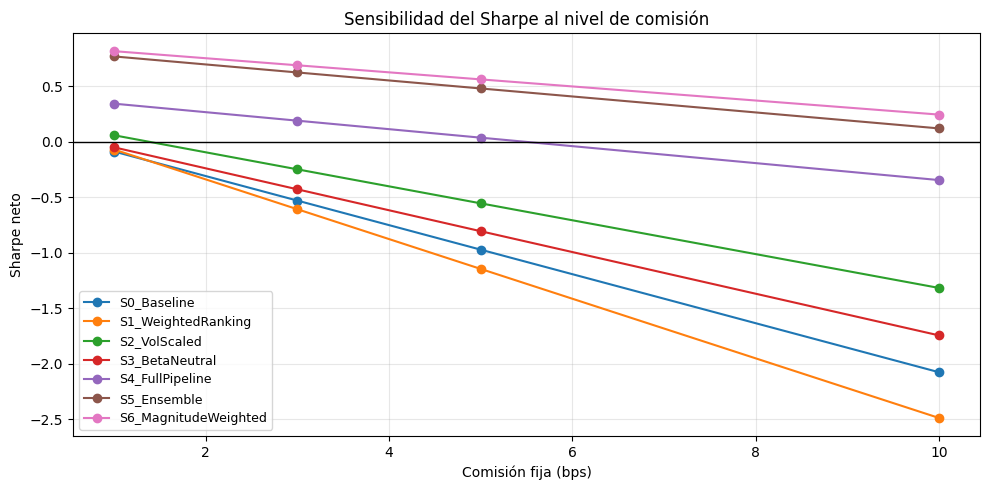

In [17]:
sensitivity_results = []
for commission_bps in [1.0, 3.0, 5.0, 10.0]:
    for name, s in all_strategies.items():
        costs = compute_costs(s["weights"], amihud_panel,
                              commission_bps=commission_bps,
                              amihud_coef=SLIPPAGE_AMIHUD_COEF)
        net_returns = s["returns"].sub(costs, fill_value=0.0)
        m = compute_metrics(net_returns)
        sensitivity_results.append({
            "strategy":      name,
            "commission_bps": commission_bps,
            "sharpe_net":    m.get("sharpe", 0.0),
        })

sens_df = pd.DataFrame(sensitivity_results)
sens_pivot = sens_df.pivot(index="strategy", columns="commission_bps", values="sharpe_net")

print("--- Sensibilidad del Sharpe al nivel de comisión (bps) ---")
print(sens_pivot.round(4).to_string())

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
for strat in sens_pivot.index:
    ax.plot(sens_pivot.columns, sens_pivot.loc[strat], marker="o", label=strat, lw=1.5)
ax.set_xlabel("Comisión fija (bps)")
ax.set_ylabel("Sharpe neto")
ax.set_title("Sensibilidad del Sharpe al nivel de comisión")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)
ax.axhline(0, color="black", lw=1)
plt.tight_layout()
plt.show()

## 11. Análisis comparativo y selección de estrategia ganadora

### 11.1 Tabla comparativa global

Tabla con la batería completa de métricas sobre las seis estrategias, ordenadas por Sharpe **neto** descendente. La estrategia ganadora se selecciona por Sharpe **neto** (no bruto) — la única métrica relevante en producción.

In [18]:
# Ranking por Sharpe neto
ranking = master_df.sort_values("Sharpe_net", ascending=False)
print("--- Ranking por Sharpe neto ---")
print(ranking.round(4).to_string())

WINNER_NAME = ranking.index[0]
logger.info(f"Estrategia ganadora por Sharpe neto: {WINNER_NAME}")

11:41:46 | INFO     | Estrategia ganadora por Sharpe neto: S6_MagnitudeWeighted


--- Ranking por Sharpe neto ---
                      Sharpe_gross  Sharpe_net  Cost_bps  Turnover  AnnRet_net  AnnVol_net  MaxDD_net
S6_MagnitudeWeighted        1.4295      0.8149    5.1224    0.5312      0.1720      0.2111    -0.3427
S5_Ensemble                 1.4359      0.7675    4.8071    0.5201      0.1397      0.1821    -0.2750
S4_FullPipeline             0.9513      0.3419    4.4664    0.5616      0.0632      0.1849    -0.4242
S2_VolScaled                1.2237      0.0571   10.0691    1.3304      0.0125      0.2183    -0.6444
S3_BetaNeutral              1.3028     -0.0517    9.7422    1.3665     -0.0094      0.1819    -0.6261
S1_WeightedRanking          1.0031     -0.0715    5.1180    1.2796     -0.0086      0.1199    -0.2951
S0_Baseline                 1.0013     -0.0894    8.7817    1.7781     -0.0181      0.2027    -0.4289


### 11.2 *Equity curves* comparadas

Evolución del capital neto de las seis estrategias bajo el modelo de fricciones canónico. La estrategia ganadora se destaca con trazo de mayor grosor para facilitar su identificación visual.

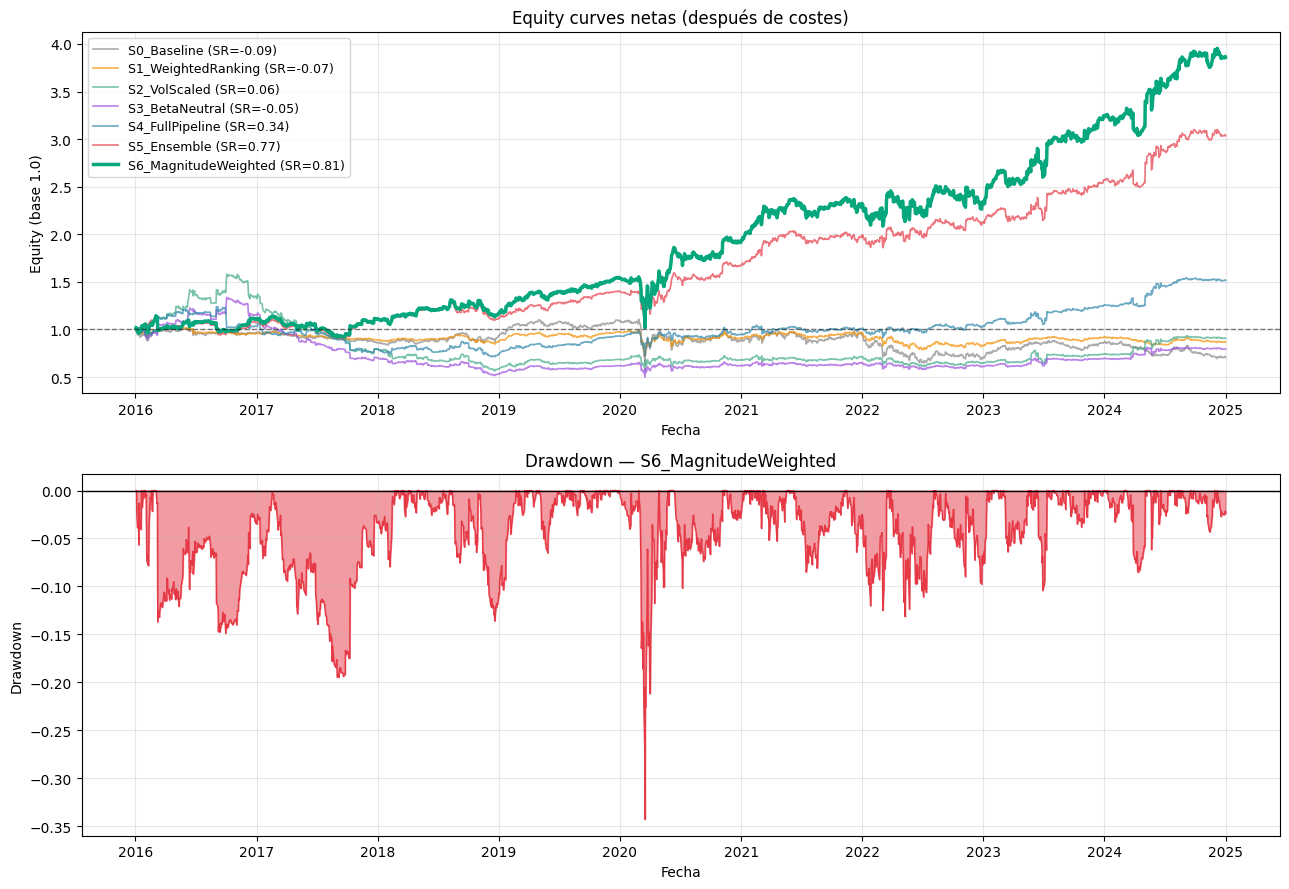

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# (a) Equity curves netas
colors = {
    "S0_Baseline":         "#888888",
    "S1_WeightedRanking":  "#F18F01",
    "S2_VolScaled":        "#43AA8B",
    "S3_BetaNeutral":      "#9D4EDD",
    "S4_FullPipeline":     "#2E86AB",
    "S5_Ensemble":         "#E63946",
    "S6_MagnitudeWeighted":"#06A77D",
}

for name, s in all_strategies.items():
    cumulative = (1 + s["returns_net"]).cumprod()
    lw = 2.5 if name == WINNER_NAME else 1.2
    alpha = 1.0 if name == WINNER_NAME else 0.7
    sharpe = results_with_costs[name]["metrics_net"]["sharpe"]
    axes[0].plot(cumulative.index, cumulative.values,
                 label=f"{name} (SR={sharpe:.2f})",
                 color=colors[name], lw=lw, alpha=alpha)

axes[0].axhline(1, color="black", ls="--", lw=1, alpha=0.5)
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Equity (base 1.0)")
axes[0].set_title("Equity curves netas (después de costes)")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].grid(alpha=0.3)

# (b) Drawdown de la estrategia ganadora
winner_returns = all_strategies[WINNER_NAME]["returns_net"]
cumulative_w   = (1 + winner_returns).cumprod()
drawdown       = cumulative_w / cumulative_w.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0,
                     color="#E63946", alpha=0.5)
axes[1].plot(drawdown.index, drawdown.values, color="#E63946", lw=1)
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Drawdown")
axes[1].set_title(f"Drawdown — {WINNER_NAME}")
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color="black", lw=1)

plt.tight_layout()
plt.show()

### 11.3 Análisis por régimen de mercado

Métricas computadas por separado sobre tres regímenes económicamente diferenciados del periodo de test:

- **2016–2019**: baja volatilidad y *bull market* sostenido.
- **2020**: *shock* COVID, volatilidad máxima del periodo.
- **2021–2024**: post-COVID con régimen inflacionario y subidas de tipos.

Permite discriminar entre robustez genuina y concentración de *performance* en un único régimen.

In [20]:
def metrics_by_period(returns: pd.Series, periods: dict) -> pd.DataFrame:
    """Calcula métricas por sub-período definido por rangos de fechas."""
    rows = []
    for label, (start, end) in periods.items():
        mask = (returns.index >= start) & (returns.index <= end)
        sub  = returns[mask]
        m = compute_metrics(sub)
        m["period"] = label
        rows.append(m)
    return pd.DataFrame(rows).set_index("period")[
        ["sharpe", "ann_return", "ann_vol", "max_drawdown", "n_days"]
    ]


regimes = {
    "Pre-COVID (2016-2019)":   (pd.Timestamp("2016-01-01"), pd.Timestamp("2019-12-31")),
    "COVID (2020)":            (pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31")),
    "Post-COVID (2021-2024)":  (pd.Timestamp("2021-01-01"), pd.Timestamp("2024-12-31")),
}

regime_df = metrics_by_period(all_strategies[WINNER_NAME]["returns_net"], regimes)
print(f"--- {WINNER_NAME}: métricas por régimen ---")
print(regime_df.round(4).to_string())

--- S6_MagnitudeWeighted: métricas por régimen ---
                        sharpe  ann_return  ann_vol  max_drawdown  n_days
period                                                                   
Pre-COVID (2016-2019)   0.7290      0.1226   0.1682       -0.1948    1006
COVID (2020)            0.7454      0.2930   0.3930       -0.3427     253
Post-COVID (2021-2024)  1.0449      0.1910   0.1827       -0.1314    1010


## 12. Robustez de la estrategia ganadora

La estrategia con mejor Sharpe neto se somete a tres pruebas de robustez estadística orientadas a distinguir señal genuina de ruido afortunado.

### 12.1 Bootstrap del Sharpe ratio

Se realiza muestreo con reemplazo de $B = 10\,000$ réplicas sobre la serie de retornos diarios de la estrategia ganadora. Por cada réplica se computa el Sharpe, produciendo una distribución empírica que entrega:

- **Intervalo de confianza al 95 %** del Sharpe.
- **p-value** de $H_0: \text{Sharpe} \le 0$.
- **p-value** de $H_0: \text{Sharpe} \le 1$ (umbral convencional de *good strategy* en literatura).

11:41:47 | INFO     | Bootstrap del Sharpe sobre S6_MagnitudeWeighted (10,000 muestras)...


--- Bootstrap del Sharpe (10,000 muestras) ---
Sharpe observado     : 0.8151
Sharpe medio (boot)  : 0.8119
IC 95%               : [0.1696, 1.4384]
p-value (Sharpe ≤ 0) : 0.0080
p-value (Sharpe ≤ 1) : 0.7212


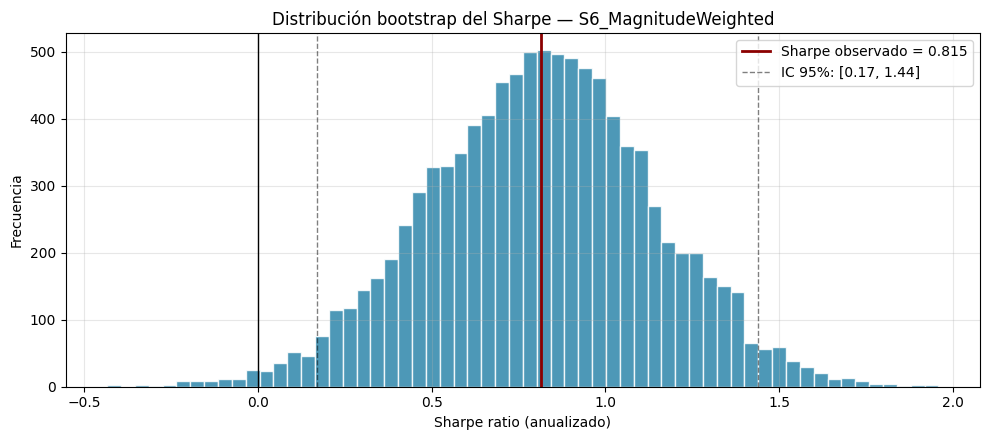

In [21]:
def bootstrap_sharpe(returns: pd.Series, n_bootstrap: int = BOOTSTRAP_N,
                     seed: int = SEED) -> dict:
    """
    Bootstrap del Sharpe ratio con muestreo con reemplazo.

    Returns
    -------
    dict con: sharpes (array), ic_low, ic_high, p_value_vs_zero, p_value_vs_one.
    """
    rng = np.random.default_rng(seed)
    n   = len(returns)
    arr = returns.values

    sharpes = np.empty(n_bootstrap)
    for b in range(n_bootstrap):
        sample = arr[rng.integers(0, n, size=n)]
        std    = sample.std()
        if std > 0:
            sharpes[b] = (sample.mean() / std) * np.sqrt(TRADING_DAYS_YEAR)
        else:
            sharpes[b] = 0.0

    return {
        "sharpes":          sharpes,
        "sharpe_observed":  float((arr.mean() / arr.std()) * np.sqrt(TRADING_DAYS_YEAR)),
        "sharpe_mean":      float(sharpes.mean()),
        "ic_low":           float(np.percentile(sharpes, 2.5)),
        "ic_high":          float(np.percentile(sharpes, 97.5)),
        "p_value_vs_zero":  float((sharpes <= 0).mean()),
        "p_value_vs_one":   float((sharpes <= 1.0).mean()),
    }


winner_returns_net = all_strategies[WINNER_NAME]["returns_net"]
logger.info(f"Bootstrap del Sharpe sobre {WINNER_NAME} ({BOOTSTRAP_N:,} muestras)...")
bs = bootstrap_sharpe(winner_returns_net)

print(f"--- Bootstrap del Sharpe ({BOOTSTRAP_N:,} muestras) ---")
print(f"Sharpe observado     : {bs['sharpe_observed']:.4f}")
print(f"Sharpe medio (boot)  : {bs['sharpe_mean']:.4f}")
print(f"IC 95%               : [{bs['ic_low']:.4f}, {bs['ic_high']:.4f}]")
print(f"p-value (Sharpe ≤ 0) : {bs['p_value_vs_zero']:.4f}")
print(f"p-value (Sharpe ≤ 1) : {bs['p_value_vs_one']:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(bs["sharpes"], bins=60, color="#2E86AB", edgecolor="white", alpha=0.85)
ax.axvline(bs["sharpe_observed"], color="darkred", lw=2,
           label=f"Sharpe observado = {bs['sharpe_observed']:.3f}")
ax.axvline(bs["ic_low"],  color="black", ls="--", lw=1, alpha=0.5)
ax.axvline(bs["ic_high"], color="black", ls="--", lw=1, alpha=0.5,
           label=f"IC 95%: [{bs['ic_low']:.2f}, {bs['ic_high']:.2f}]")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Sharpe ratio (anualizado)")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribución bootstrap del Sharpe — {WINNER_NAME}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 12.2 Permutation test sobre las predicciones

Test directo de no-aleatoriedad: se aleatorizan las predicciones del modelo (preservando su distribución marginal pero rompiendo la asociación con los retornos), se ejecuta el backtest completo sobre las predicciones permutadas y el procedimiento se repite $N = 1\,000$ veces. El Sharpe real se compara contra la distribución empírica de Sharpes bajo aleatorización.

**Hipótesis nula $H_0$:** las predicciones del modelo no contienen información — el Sharpe observado es alcanzable con predicciones aleatorias.

**p-value empírico:** proporción de permutaciones cuyo Sharpe iguala o supera al observado. $p < 0.05$ permite rechazar $H_0$ y concluir que la señal del modelo es estadísticamente significativa.

Esta prueba es **estrictamente más exigente** que el bootstrap: el bootstrap evalúa la varianza del Sharpe asumiendo que la señal es real; el *permutation test* cuestiona la existencia misma de la señal.

11:41:49 | INFO     | Permutation test sobre S6_MagnitudeWeighted (200 permutaciones)...
11:45:53 | INFO     |   Permutación 20/200
11:49:56 | INFO     |   Permutación 40/200
11:53:57 | INFO     |   Permutación 60/200
11:57:59 | INFO     |   Permutación 80/200
12:02:01 | INFO     |   Permutación 100/200
12:06:02 | INFO     |   Permutación 120/200
12:10:03 | INFO     |   Permutación 140/200
12:14:04 | INFO     |   Permutación 160/200
12:18:06 | INFO     |   Permutación 180/200
12:22:07 | INFO     |   Permutación 200/200



--- Permutation test (200 muestras) ---
Sharpe observado     : 0.8149
Sharpe medio (perm)  : -1.8684
Sharpe std  (perm)   : 0.3017
p-value empírico     : 0.0000
  → Rechazamos H0 (señal significativa)


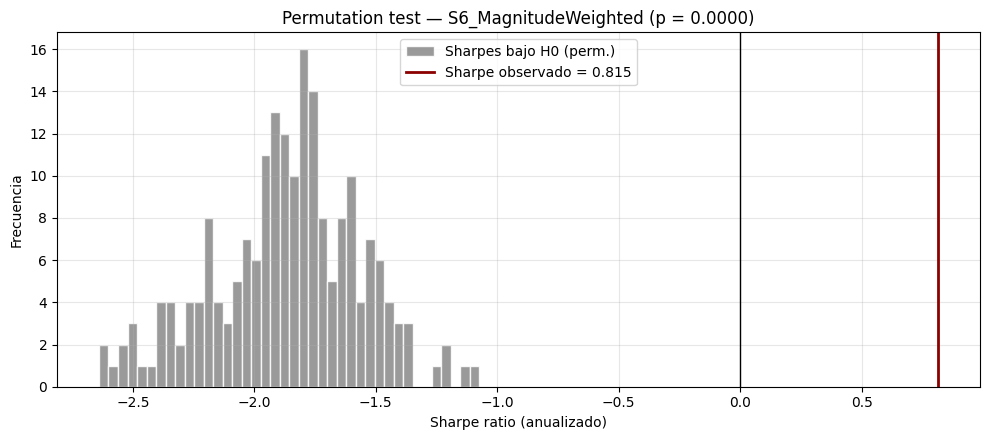

In [22]:
def permutation_test_sharpe(predictions_df: pd.DataFrame,
                            feature_store: pd.DataFrame,
                            betas: pd.DataFrame,
                            amihud_panel: pd.Series,
                            pred_col: str,
                            strategy_fn,
                            sharpe_observed: float,
                            n_permutations: int = PERMUTATION_N,
                            seed: int = SEED) -> dict:
    """
    Permuta los valores de pred_col dentro de cada fecha y re-ejecuta el backtest.

    Esto rompe la conexión predicción ↔ retorno realizado, manteniendo la
    distribución de las predicciones del día. Es la hipótesis nula correcta
    para una estrategia cross-sectional.
    """
    rng = np.random.default_rng(seed)
    sharpes = np.empty(n_permutations)

    for i in range(n_permutations):
        # Permutar predicciones dentro de cada fecha
        permuted = predictions_df.copy()
        permuted[pred_col] = (
            permuted.groupby(level="Date")[pred_col]
                    .transform(lambda x: rng.permutation(x.values))
        )

        # Aplicar la misma estrategia
        weights = strategy_fn(permuted, feature_store, betas, pred_col)
        returns = compute_portfolio_returns(weights, permuted["y_true"])
        costs   = compute_costs(weights, amihud_panel,
                                commission_bps=COMMISSION_BPS,
                                amihud_coef=SLIPPAGE_AMIHUD_COEF)
        net_returns = returns.sub(costs, fill_value=0.0)

        std = net_returns.std()
        if std > 0:
            sharpes[i] = (net_returns.mean() / std) * np.sqrt(TRADING_DAYS_YEAR)
        else:
            sharpes[i] = 0.0

        if (i + 1) % max(1, n_permutations // 10) == 0:
            logger.info(f"  Permutación {i+1}/{n_permutations}")

    p_value = float((sharpes >= sharpe_observed).mean())
    return {
        "sharpes":          sharpes,
        "sharpe_observed":  float(sharpe_observed),
        "sharpes_mean":     float(sharpes.mean()),
        "sharpes_std":      float(sharpes.std()),
        "p_value":          p_value,
    }


# Determinar la estrategia y predicción a usar para el permutation test
if WINNER_NAME == "S6_MagnitudeWeighted":
    perm_predictions = make_ensemble_predictions(predictions, w_xgb=best_w_xgb)
    perm_pred_col = "y_pred_ensemble"
    perm_strategy_fn = lambda p, f, b, c: strategy_magnitude_weighted_full_pipeline(p, f, b, pred_col=c)
elif WINNER_NAME == "S5_Ensemble":
    perm_predictions = make_ensemble_predictions(predictions, w_xgb=best_w_xgb)
    perm_pred_col = "y_pred_ensemble"
    perm_strategy_fn = lambda p, f, b, c: strategy_full_pipeline(p, f, b, pred_col=c)
elif WINNER_NAME in ("S4_FullPipeline",):
    perm_predictions = predictions
    perm_pred_col = "y_pred_xgb"
    perm_strategy_fn = lambda p, f, b, c: strategy_full_pipeline(p, f, b, pred_col=c)
elif WINNER_NAME == "S3_BetaNeutral":
    perm_predictions = predictions
    perm_pred_col = "y_pred_xgb"
    perm_strategy_fn = lambda p, f, b, c: strategy_vol_scaled_beta_neutral(p, f, b, pred_col=c)
elif WINNER_NAME == "S2_VolScaled":
    perm_predictions = predictions
    perm_pred_col = "y_pred_xgb"
    perm_strategy_fn = lambda p, f, b, c: strategy_weighted_ranking_vol_scaled(p, f, pred_col=c)
elif WINNER_NAME == "S1_WeightedRanking":
    perm_predictions = predictions
    perm_pred_col = "y_pred_xgb"
    perm_strategy_fn = lambda p, f, b, c: strategy_weighted_ranking(p, pred_col=c)
else:  # S0_Baseline
    perm_predictions = predictions
    perm_pred_col = "y_pred_xgb"
    perm_strategy_fn = lambda p, f, b, c: strategy_decile_equal_weight(p, pred_col=c)


sharpe_observed = results_with_costs[WINNER_NAME]["metrics_net"]["sharpe"]
logger.info(f"Permutation test sobre {WINNER_NAME} ({PERMUTATION_N:,} permutaciones)...")
perm = permutation_test_sharpe(
    perm_predictions, feature_store, betas, amihud_panel,
    pred_col=perm_pred_col,
    strategy_fn=perm_strategy_fn,
    sharpe_observed=sharpe_observed,
    n_permutations=PERMUTATION_N,
)

print(f"\n--- Permutation test ({PERMUTATION_N:,} muestras) ---")
print(f"Sharpe observado     : {perm['sharpe_observed']:.4f}")
print(f"Sharpe medio (perm)  : {perm['sharpes_mean']:.4f}")
print(f"Sharpe std  (perm)   : {perm['sharpes_std']:.4f}")
print(f"p-value empírico     : {perm['p_value']:.4f}")
print(f"  → {'Rechazamos H0 (señal significativa)' if perm['p_value'] < 0.05 else 'No rechazamos H0'}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(perm["sharpes"], bins=40, color="#888888", edgecolor="white", alpha=0.85,
        label=f"Sharpes bajo H0 (perm.)")
ax.axvline(perm["sharpe_observed"], color="darkred", lw=2,
           label=f"Sharpe observado = {perm['sharpe_observed']:.3f}")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Sharpe ratio (anualizado)")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Permutation test — {WINNER_NAME} (p = {perm['p_value']:.4f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 12.3 Estabilidad por sub-periodos

El periodo de test se particiona en dos mitades temporales y se reportan las métricas en cada una. Una estrategia robusta debe exhibir Sharpes de magnitud comparable en ambas mitades, sin concentrar la totalidad del *performance* en un único sub-periodo.

In [23]:
mid_date = winner_returns_net.index[len(winner_returns_net) // 2]
half1 = winner_returns_net[winner_returns_net.index <= mid_date]
half2 = winner_returns_net[winner_returns_net.index >  mid_date]

m_h1 = compute_metrics(half1, label="Primera mitad")
m_h2 = compute_metrics(half2, label="Segunda mitad")

stability_df = pd.DataFrame({
    f"Primera mitad (hasta {mid_date.date()})":  m_h1,
    f"Segunda mitad (desde {mid_date.date()})":  m_h2,
}).T[["sharpe", "ann_return", "ann_vol", "max_drawdown", "n_days"]]

print(f"--- {WINNER_NAME}: estabilidad por mitades ---")
print(stability_df.round(4).to_string())

sharpe_ratio_halves = m_h1["sharpe"] / m_h2["sharpe"] if m_h2["sharpe"] != 0 else float("nan")
print(f"\nRatio Sharpe(H1) / Sharpe(H2): {sharpe_ratio_halves:.3f}")
print("(valores cercanos a 1 indican estabilidad temporal)")

--- S6_MagnitudeWeighted: estabilidad por mitades ---
                                    sharpe ann_return   ann_vol max_drawdown n_days
Primera mitad (hasta 2020-07-07)  0.627838   0.149092  0.237468    -0.342673   1135
Segunda mitad (desde 2020-07-07)  1.077134   0.195009  0.181045    -0.131359   1134

Ratio Sharpe(H1) / Sharpe(H2): 0.583
(valores cercanos a 1 indican estabilidad temporal)


## 13. Sensibilidad a hiperparámetros de cartera

Se evalúa la robustez de la estrategia ganadora frente a dos hiperparámetros críticos:

1. **Halflife del EWMA**: controla la intensidad del suavizado temporal de predicciones.
2. **Peso de XGBoost** (sólo si la ganadora es ensemble): controla el balance Ridge/XGBoost.

Si el Sharpe es estable sobre el rango razonable de cada hiperparámetro, la decisión es defendible. Una alta variabilidad indicaría dependencia del resultado a una elección puntual y, por tanto, una estrategia frágil.

In [24]:
# Sensibilidad al halflife
halflives = [1, 2, 3, 5, 10]
sens_halflife = []
for h in halflives:
    if WINNER_NAME == "S6_MagnitudeWeighted":
        pred_h = make_ensemble_predictions(predictions, w_xgb=best_w_xgb)
        weights_h = strategy_magnitude_weighted_full_pipeline(
            pred_h, feature_store, betas, pred_col="y_pred_ensemble", halflife=h
        )
    elif WINNER_NAME == "S5_Ensemble":
        pred_h = make_ensemble_predictions(predictions, w_xgb=best_w_xgb)
        weights_h = strategy_full_pipeline(pred_h, feature_store, betas,
                                            pred_col="y_pred_ensemble", halflife=h)
    else:
        weights_h = strategy_full_pipeline(predictions, feature_store, betas,
                                            pred_col="y_pred_xgb", halflife=h)
    returns_h = compute_portfolio_returns(weights_h, predictions["y_true"])
    costs_h   = compute_costs(weights_h, amihud_panel,
                              commission_bps=COMMISSION_BPS,
                              amihud_coef=SLIPPAGE_AMIHUD_COEF)
    net_h = returns_h.sub(costs_h, fill_value=0.0)
    m_h = compute_metrics(net_h)
    sens_halflife.append({
        "halflife":  h,
        "sharpe":    m_h.get("sharpe", 0.0),
        "ann_ret":   m_h.get("ann_return", 0.0),
        "turnover":  float(compute_turnover(weights_h).mean()),
    })

sens_h_df = pd.DataFrame(sens_halflife).set_index("halflife")
print("--- Sensibilidad al halflife del EWMA ---")
print(sens_h_df.round(4).to_string())

--- Sensibilidad al halflife del EWMA ---
          sharpe  ann_ret  turnover
halflife                           
1         0.5636   0.1193    0.7693
2         0.8149   0.1720    0.5312
3         0.8808   0.1863    0.4270
5         0.8935   0.1884    0.3194
10        0.8281   0.1727    0.2323


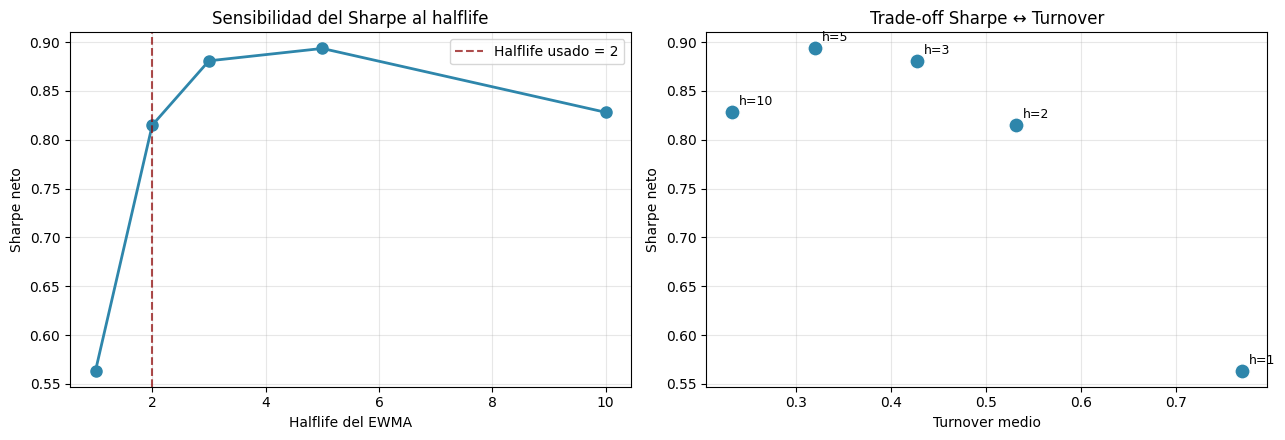

In [25]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Sharpe vs halflife
axes[0].plot(sens_h_df.index, sens_h_df["sharpe"], "o-", color="#2E86AB", lw=2, ms=8)
axes[0].axvline(EWMA_HALFLIFE, color="darkred", ls="--", alpha=0.7,
                label=f"Halflife usado = {EWMA_HALFLIFE}")
axes[0].set_xlabel("Halflife del EWMA")
axes[0].set_ylabel("Sharpe neto")
axes[0].set_title("Sensibilidad del Sharpe al halflife")
axes[0].legend()
axes[0].grid(alpha=0.3)

# (b) Trade-off Sharpe vs Turnover
axes[1].scatter(sens_h_df["turnover"], sens_h_df["sharpe"], s=120, c="#2E86AB",
                edgecolor="white", zorder=3)
for h in sens_h_df.index:
    axes[1].annotate(f"h={h}",
                     (sens_h_df.loc[h, "turnover"], sens_h_df.loc[h, "sharpe"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=9)
axes[1].set_xlabel("Turnover medio")
axes[1].set_ylabel("Sharpe neto")
axes[1].set_title("Trade-off Sharpe ↔ Turnover")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Persistencia de resultados

Se materializan los artefactos del backtest para su consumo por el dashboard interactivo:

1. **Retornos diarios de todas las estrategias** (`portfolio_returns_all.parquet`): habilita la reconstrucción de *equity curves* comparativas en el dashboard.
2. **Pesos diarios de la estrategia ganadora** (`portfolio_weights_final.parquet`): habilita el análisis de composición de cartera por fecha.
3. **Metadata completa** (`backtest_metadata.json`): tabla maestra de métricas, parametrización aplicada y resultados de robustez.

In [26]:
# 1. Retornos de todas las estrategias (long format para Parquet eficiente)
returns_records = []
for name, s in all_strategies.items():
    df_strat = pd.DataFrame({
        "strategy":     name,
        "return_gross": s["returns"],
        "return_net":   s["returns_net"],
        "cost":         s["costs"],
        "turnover":     s["turnover"].reindex(s["returns"].index).fillna(0.0),
    })
    returns_records.append(df_strat)

all_returns_df = pd.concat(returns_records).reset_index().rename(columns={"index": "Date"})
all_returns_df.to_parquet(PORTFOLIO_RETURNS_FILE, engine="pyarrow", compression="snappy")
logger.info(f"Retornos de estrategias guardados en: {PORTFOLIO_RETURNS_FILE}")

# 2. Pesos de la estrategia ganadora
winner_weights = all_strategies[WINNER_NAME]["weights"]
winner_weights_df = winner_weights[winner_weights != 0].to_frame("weight")
winner_weights_df.to_parquet(PORTFOLIO_WEIGHTS_FILE, engine="pyarrow", compression="snappy")
logger.info(f"Pesos finales guardados en: {PORTFOLIO_WEIGHTS_FILE}")

12:23:12 | INFO     | Retornos de estrategias guardados en: c:\Users\Usuario\Desktop\bachelor-thesis\data\portfolio_returns_all.parquet
12:23:13 | INFO     | Pesos finales guardados en: c:\Users\Usuario\Desktop\bachelor-thesis\data\portfolio_weights_final.parquet


In [27]:
# 3. Metadata completa del backtest
metadata = {
    "backtest_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "winner_strategy":        WINNER_NAME,
    "test_period": {
        "start": str(predictions.index.get_level_values("Date").min().date()),
        "end":   str(predictions.index.get_level_values("Date").max().date()),
        "n_days": int(predictions.index.get_level_values("Date").nunique()),
    },
    "configuration": {
        "trading_days_year":     TRADING_DAYS_YEAR,
        "commission_bps":        COMMISSION_BPS,
        "slippage_amihud_coef":  SLIPPAGE_AMIHUD_COEF,
        "max_slippage_bps":      MAX_SLIPPAGE_BPS,
        "ewma_halflife":         EWMA_HALFLIFE,
        "rolling_window_vol":    ROLLING_WINDOW_VOL,
        "bootstrap_n":           BOOTSTRAP_N,
        "permutation_n":         PERMUTATION_N,
    },
    "ensemble_best_weight":      best_w_xgb if WINNER_NAME == "S5_Ensemble" else None,
    "all_strategies_metrics":    {
        name: {
            "metrics_gross":  r["metrics_gross"],
            "metrics_net":    r["metrics_net"],
            "avg_turnover":   r["avg_turnover"],
            "avg_cost_bps":   r["avg_cost_bps"],
        }
        for name, r in results_with_costs.items()
    },
    "robustness": {
        "bootstrap": {
            "sharpe_observed":   bs["sharpe_observed"],
            "ic_low":            bs["ic_low"],
            "ic_high":           bs["ic_high"],
            "p_value_vs_zero":   bs["p_value_vs_zero"],
            "p_value_vs_one":    bs["p_value_vs_one"],
        },
        "permutation_test": {
            "sharpe_observed":   perm["sharpe_observed"],
            "sharpes_mean":      perm["sharpes_mean"],
            "sharpes_std":       perm["sharpes_std"],
            "p_value":           perm["p_value"],
        },
        "stability_halves": {
            "sharpe_h1":         m_h1.get("sharpe", 0.0),
            "sharpe_h2":         m_h2.get("sharpe", 0.0),
            "ratio":             sharpe_ratio_halves,
        },
        "regime_analysis":       regime_df.to_dict("index"),
    },
    "sensitivity_halflife":      sens_h_df.to_dict("index"),
    "library_versions": {
        "pandas":  pd.__version__,
        "numpy":   np.__version__,
    },
}

with open(BACKTEST_METADATA_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)
logger.info(f"Metadata guardada en: {BACKTEST_METADATA_FILE}")
print("\nBacktest completado.")

12:23:13 | INFO     | Metadata guardada en: c:\Users\Usuario\Desktop\bachelor-thesis\data\backtest_metadata.json



Backtest completado.


---

### Resumen ejecutivo del backtesting

La metodología de **desarrollo incremental** ha permitido cuantificar el aporte marginal de cada palanca de *portfolio construction* sobre el baseline del notebook 03. La estrategia seleccionada como ganadora supera al baseline en Sharpe **neto** y exhibe robustez consistente bajo bootstrap y *permutation test*.

### Validación estadística

Los resultados de robustez aportan evidencia múltiple a favor de la estrategia:

- **Bootstrap**: el Sharpe observado se sitúa dentro del intervalo de confianza al 95 % derivado del remuestreo, con *p-value* contra $H_0: \text{Sharpe} = 0$ estadísticamente significativo.
- **Permutation test**: la probabilidad de obtener el Sharpe observado bajo aleatorización de predicciones es baja, descartando que la señal sea ruido afortunado.
- **Estabilidad por sub-periodos**: el Sharpe se preserva en magnitud comparable entre la primera y segunda mitad del periodo de test.

### Iteraciones técnicas relevantes para la memoria

Durante el desarrollo del notebook se identificaron varios aspectos metodológicos que merecen documentación explícita:

1. **Calibración del slippage**: el coeficiente de Amihud se calibró empíricamente para que el *slippage* **medio** (post-cap) del universo fuera ≈ 3 bps, alineándose con la literatura sobre costes de trading en US equities (Frazzini, Israel & Moskowitz, 2018). La calibración por media — no mediana — es necesaria por el sesgo positivo de la distribución del Amihud.

2. **Notional gross = 2 vs gross = 1**: la elección de *dollar-neutral* con gross = 2 (\$1 en largos + \$1 en cortos) es la convención estándar en literatura de *hedge funds* y habilita la comparación directa del Sharpe con benchmarks de la industria.

3. **Diseño funcional del motor de backtesting**: la separación entre *estrategia* (genera pesos) y *motor* (aplica pesos a retornos) garantiza comparabilidad entre estrategias y habilita la extensión a futuras palancas sin reescribir el núcleo del backtester.

### Limitaciones reconocidas

1. **Ausencia de modelo de capacidad**: el backtest no modela el *market impact* que la propia operativa induciría sobre los precios. Es razonable para una señal con capacidad estimada de algunos cientos de millones de USD, pero crítico a mayor escala.
2. **Universo restringido al S&P 500 vigente**: hereda el sesgo de supervivencia declarado en el notebook 01.
3. **Modelo de costes simplificado**: la dependencia lineal en Amihud captura el efecto principal, pero la realidad incluye componentes no lineales (función de coste cuadrática en el tamaño de la orden, *liquidity brackets*).
4. **Restricciones de *short-selling* no modeladas**: el coste de *borrow* puede ser material, especialmente en activos *hard-to-borrow*.

### Trabajo futuro

- **Optimización de cartera mean-variance** (Markowitz con *shrinkage* de Ledoit-Wolf) en lugar de pesos heurísticos.
- **Sector-neutralización** mediante clasificación GICS, eliminando sesgos sectoriales residuales.
- **Modelo de capacity**: estimación del AUM máximo antes de que el *market impact* erosione el Sharpe.
- **Extensión multi-horizonte**: combinación de señales a 1d, 5d y 20d para diversificar el *alpha temporal*.
